## project:

Understanding customer preferences and restaurant trends is important for making informed business decisions in food industry. In this article, we will analyze Zomato’s restaurant dataset using Python to find meaningful insights. We aim to answer questions such as:

* Do more restaurants provide online delivery compared to offline services?
* Which types of restaurants are most favored by the general public?
* What price range do couples prefer for dining out?

In [ ]:
# imoprting required libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
# pandas & numpy are used for calculating the data,matplotlib & seaborn are used for creating chats&graphs.

In [15]:
# reading the file.

df = pd.read_csv(r"C:\Users\PRAVEEN\OneDrive\Desktop\data analytics  notes & files\Data sets\Data sets\Zomato-data-.csv")

In [14]:
df.info() # this function is used to know the information of the data set.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


### Creataing a DataProfile :
- it gives complete overview about the data set.

In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df)
profile.to_file('zomato_restaurant.html')
print("report saved to 'zomato_restaurant.html'")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:00<00:00, 151.86it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

report saved to 'zomato_restaurant.html'


### Data cleaning and Preparation:


1. Checking for missing or null values.

In [ ]:
df.isnull().sum()# checking for missing values.

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

* There are no null values in the data set.

2. Convert the rate column to a float by removing denominator characters.

In [ ]:
df['rate']=df['rate'].str.split('/').str[0].astype(float)#now the data is normal form.

In [ ]:
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


### Exploring Restaurant Types:


Text(0.5, 0, 'Type of restaurant')

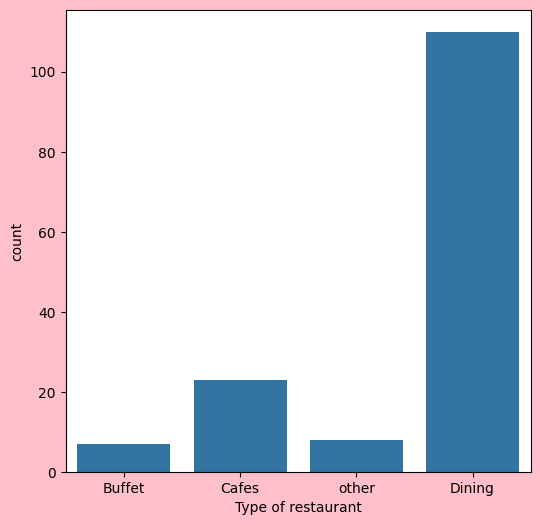

In [ ]:
plt.figure(figsize=(6,6),facecolor='pink')
sns.countplot(x=df['listed_in(type)'])
plt.xlabel('Type of restaurant')

Text(0, 0.5, 'votes')

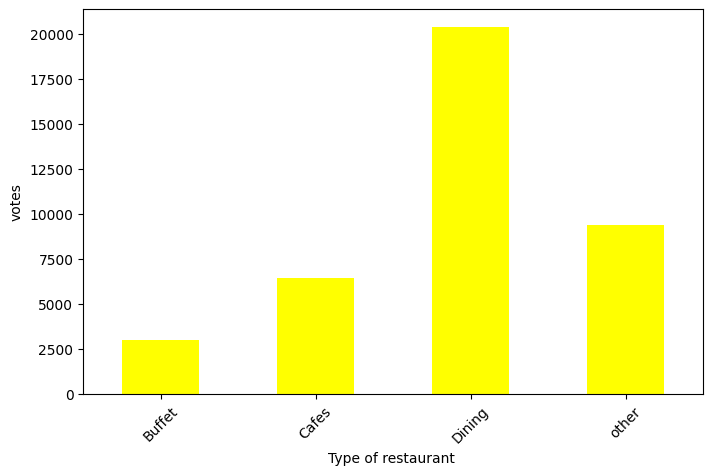

In [ ]:
grouped_data=df.groupby('listed_in(type)')['votes']
res=pd.DataFrame({'votes':grouped_data})
votes_sum = grouped_data.sum()
plt.figure(figsize=(8,5))
votes_sum.plot(kind='bar', color='yellow', rot=45)
plt.xlabel('Type of restaurant ')
plt.ylabel('votes')

In [ ]:
# Identify the most voted restaurant
max_votes=df['votes'].max()
restaurant_with_max_votes=df.loc[df['votes']==max_votes,"name"]
print('Restaurant(s) with the max votes: ')
print(restaurant_with_max_votes)

Restaurant(s) with the max votes: 
38    Empire Restaurant
Name: name, dtype: str


<Axes: xlabel='online_order', ylabel='count'>

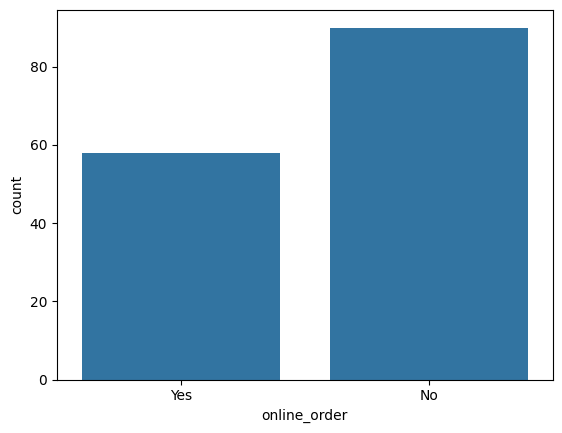

In [ ]:
# online orders avalibity:
sns.countplot(x=df['online_order'])

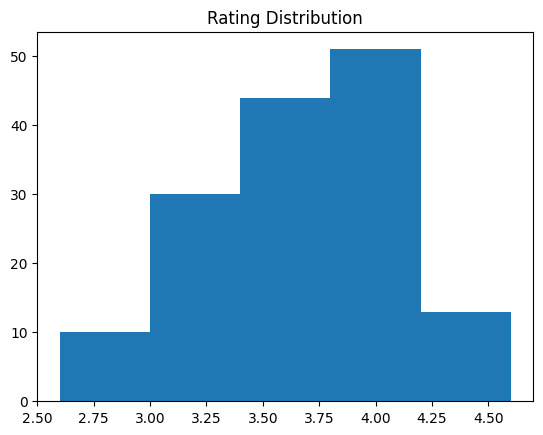

In [ ]:
# Analyzeing Rating:
plt.hist(df['rate'],bins=5)
plt.title('Rating Distribution')
plt.show()

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

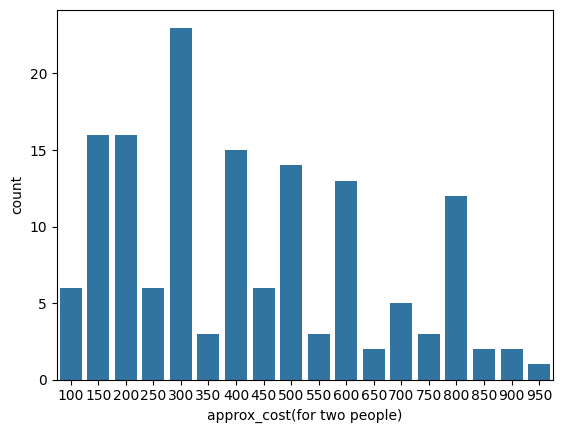

In [ ]:
# Approximate Cost for Couples:
couple_data=df['approx_cost(for two people)']
sns.countplot(x=couple_data)

<Axes: xlabel='online_order', ylabel='rate'>

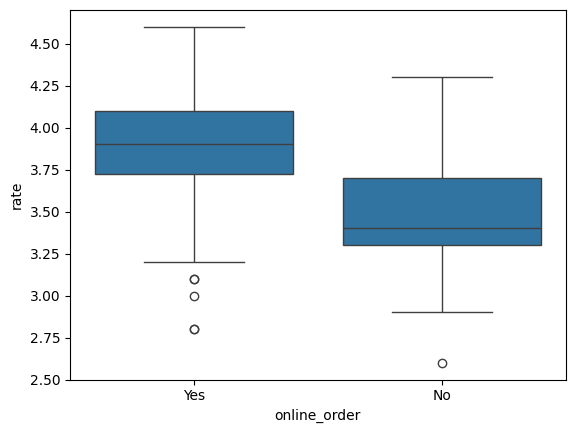

In [ ]:
# Rating Compresion - online vs offline
sns.boxplot(x='online_order',y='rate',data=df)

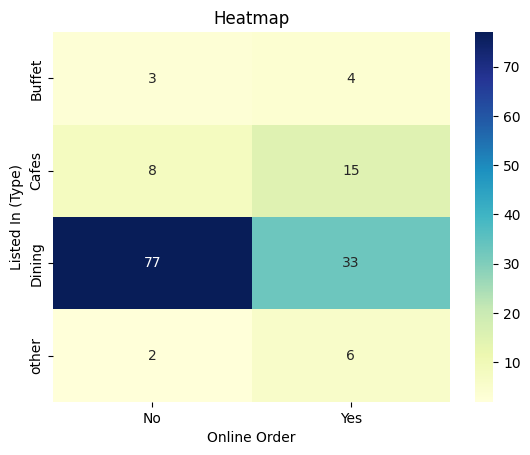

In [ ]:
# Order Mode Preferences by Restaurant Type:
pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()